In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [13]:
def fetch_stock_data(ticker, start_date, end_date):
    """
    Fetch historical stock data from Yahoo Finance.

    Args:
        ticker (str): Stock ticker symbol (e.g., 'AAPL')
        start_date (str): Start date in 'YYYY-MM-DD' format
        end_date (str): End date in 'YYYY-MM-DD' format

    Returns:
        pd.DataFrame: Historical stock data
    """
    print(f"Fetching data for {ticker}...")
    data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    print(f"Data fetched: {len(data)} records")
    return data

In [14]:
#  FEATURE ENGINEERING

def prepare_features(data):
    """
    Prepare features and target variable for prediction.
    Creates next-day close price as target by shifting.

    Args:
        data (pd.DataFrame): Raw stock data

    Returns:
        pd.DataFrame: Processed dataframe with features and target
    """
    # Create a copy to avoid modifying original data
    df = data.copy()

    # Select relevant features: Open, High, Low, Volume
    feature_columns = ['Open', 'High', 'Low', 'Volume']
    df = df[feature_columns + ['Close']]

    # Create target: Next day's closing price
    # Shift Close price by -1 to get tomorrow's price as target
    df['Target'] = df['Close'].shift(-1)

    # Drop the last row (no target available for the last day)
    df = df.dropna()

    print(f"Features prepared. Shape: {df.shape}")
    return df

In [15]:
# TRAIN-TEST SPLIT

def time_series_split(df, test_size=0.2):
    """
    Split data into training and testing sets for time series.
    Maintains temporal order (no shuffling).

    Args:
        df (pd.DataFrame): Prepared dataframe
        test_size (float): Proportion of data for testing

    Returns:
        tuple: X_train, X_test, y_train, y_test
    """
    # Calculate split index
    split_idx = int(len(df) * (1 - test_size))

    # Define features (X) and target (y)
    feature_columns = ['Open', 'High', 'Low', 'Volume']
    X = df[feature_columns]
    y = df['Target']

    # Split maintaining temporal order
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    print(f"Train set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")

    return X_train, X_test, y_train, y_test


In [16]:
#MODEL TRAINING

def train_linear_regression(X_train, y_train):
    """
    Train a Linear Regression model.

    Args:
        X_train: Training features
        y_train: Training target

    Returns:
        LinearRegression: Trained model
    """
    print("\nTraining Linear Regression model...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    print("Linear Regression training complete.")
    return lr_model


def train_random_forest(X_train, y_train):
    """
    Train a Random Forest Regressor model.

    Args:
        X_train: Training features
        y_train: Training target

    Returns:
        RandomForestRegressor: Trained model
    """
    print("\nTraining Random Forest model...")
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    print("Random Forest training complete.")
    return rf_model

In [17]:

# MODEL EVALUATION

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate model performance using MAE and RMSE metrics.

    Args:
        model: Trained model
        X_test: Test features
        y_test: Test target
        model_name (str): Name of the model for display

    Returns:
        tuple: predictions, MAE, RMSE
    """
    # Make predictions
    predictions = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    print(f"\n{model_name} Performance:")
    print(f"  Mean Absolute Error (MAE): ${mae:.2f}")
    print(f"  Root Mean Squared Error (RMSE): ${rmse:.2f}")

    return predictions, mae, rmse

In [18]:
def plot_predictions(y_test, lr_predictions, rf_predictions, ticker):
    """
    Plot actual vs predicted stock prices for both models.

    Args:
        y_test: Actual test values
        lr_predictions: Linear Regression predictions
        rf_predictions: Random Forest predictions
        ticker (str): Stock ticker symbol
    """
    plt.figure(figsize=(14, 6))

    # Create x-axis (test set indices)
    x_axis = range(len(y_test))

    # Plot actual prices
    plt.plot(x_axis, y_test.values, label='Actual Close Price',
             color='black', linewidth=2, marker='o', markersize=3)

    # Plot Linear Regression predictions
    plt.plot(x_axis, lr_predictions, label='Linear Regression Predictions',
             color='blue', linewidth=1.5, linestyle='--', alpha=0.7)

    # Plot Random Forest predictions
    plt.plot(x_axis, rf_predictions, label='Random Forest Predictions',
             color='green', linewidth=1.5, linestyle='--', alpha=0.7)

    # Formatting
    plt.title(f'{ticker} Stock Price Prediction: Actual vs Predicted',
              fontsize=16, fontweight='bold')
    plt.xlabel('Test Set Time Steps', fontsize=12)
    plt.ylabel('Stock Price ($)', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save and show
    plt.savefig(f'{ticker}_prediction_results.png', dpi=300, bbox_inches='tight')
    print(f"\nPlot saved as '{ticker}_prediction_results.png'")
    plt.show()



In [26]:
# MAIN EXECUTION

def main():
    """
    Main function to orchestrate the entire ML pipeline.
    """

    print("STOCK PRICE PREDICTION SYSTEM")


    # Configuration
    TICKER = 'AAPL'
    START_DATE = '2020-01-01'
    END_DATE = '2024-12-31'
    TEST_SIZE = 0.2

    # Step 1: Fetch data
    raw_data = fetch_stock_data(TICKER, START_DATE, END_DATE)

    # Step 2: Prepare features
    processed_data = prepare_features(raw_data)

    # Step 3: Split data
    X_train, X_test, y_train, y_test = time_series_split(
        processed_data,
        test_size=TEST_SIZE
    )

    # Step 4: Train models
    lr_model = train_linear_regression(X_train, y_train)
    rf_model = train_random_forest(X_train, y_train)

    # Step 5: Evaluate models
    lr_predictions, lr_mae, lr_rmse = evaluate_model(
        lr_model, X_test, y_test, "Linear Regression"
    )
    rf_predictions, rf_mae, rf_rmse = evaluate_model(
        rf_model, X_test, y_test, "Random Forest"
    )

    # Step 6: Visualize results
    plot_predictions(y_test, lr_predictions, rf_predictions, TICKER)

    # Summary

    print("PREDICTION SUMMARY")

    print(f"Stock: {TICKER}")
    print(f"Test Period: {len(y_test)} trading days")
    print(f"\nLinear Regression  - MAE: ${lr_mae:.2f}, RMSE: ${lr_rmse:.2f}")
    print(f"Random Forest      - MAE: ${rf_mae:.2f}, RMSE: ${rf_rmse:.2f}")

    # Determine better model
    if rf_mae < lr_mae:
        print(f"\n✓ Random Forest performs better (lower MAE by ${lr_mae - rf_mae:.2f})")
    else:
        print(f"\nLinear Regression performs better (lower MAE by ${rf_mae - lr_mae:.2f})")





STOCK PRICE PREDICTION SYSTEM
Fetching data for AAPL...
Data fetched: 1257 records
Features prepared. Shape: (1256, 6)
Train set size: 1004
Test set size: 252

Training Linear Regression model...
Linear Regression training complete.

Training Random Forest model...
Random Forest training complete.

Linear Regression Performance:
  Mean Absolute Error (MAE): $2.34
  Root Mean Squared Error (RMSE): $3.10

Random Forest Performance:
  Mean Absolute Error (MAE): $19.07
  Root Mean Squared Error (RMSE): $25.78

Plot saved as 'AAPL_prediction_results.png'


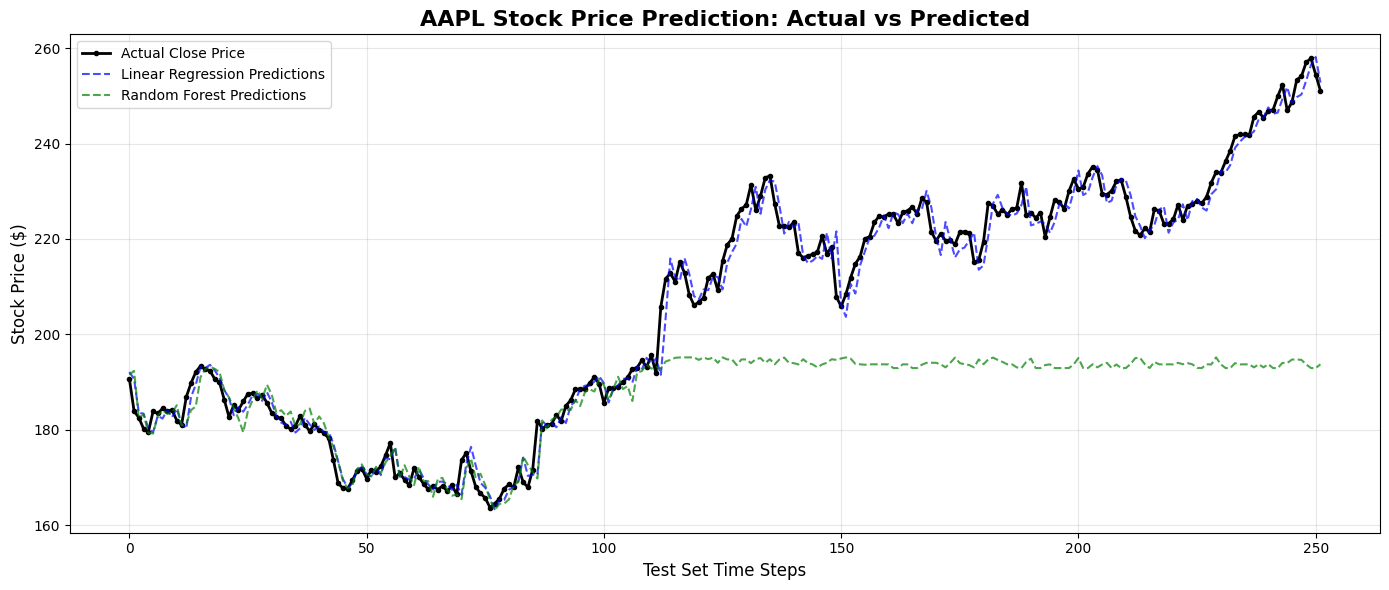

PREDICTION SUMMARY
Stock: AAPL
Test Period: 252 trading days

Linear Regression  - MAE: $2.34, RMSE: $3.10
Random Forest      - MAE: $19.07, RMSE: $25.78

Linear Regression performs better (lower MAE by $16.74)


In [27]:
# ENTRY POINT

if __name__ == "__main__":
    main()